In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Linda Octaviani'
NIM  = '244107020002'          

N     = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  : Linda Octaviani
NIM   : 244107020002 | N = 2
bins   : 32
clip   : 2.0
tile   : 4
L      : 8
WAKTU : 2026-10-02 17:01:42 WIB
SISTEM: 3.12.3 Linux-6.18.44-fc-v51-x86_64-with-glibc2.39
TOKEN : 108679307fc6e631


## Perhitungan parameter pribadi (N = 002 → N = 2)

| Simbol | Rumus | Perhitungan | Nilai |
|---|---|---|---|
| bins | 2^((N mod 4)+3) | 2^((2 mod 4)+3) = 2^5 | **32** |
| clip | 1,0 + (N mod 5) × 0,5 | 1,0 + 2 × 0,5 | **2,0** |
| tile | (N mod 4) + 2 | 2 + 2 | **4** |
| L | 2^((N mod 3)+1) | 2^((2 mod 3)+1) = 2^3 | **8** |

**Pemetaan berkas:** KTM1a = difoto di ruangan gelap, KTM1b = lampu ruangan, KTM1c = flash, KTM1d = luar ruangan (cahaya matahari).
Seluruh citra KTM sudah di-crop agar tidak ada latar belakang (tepi plastik/meja, footer CamScanner) lalu diperkecil ke lebar 800 px agar perulangan manual (for y … for x …) selesai dalam hitungan detik.
lena_lc.jpg tidak ikut terunggah, sehingga dibuat sendiri dari lena.jpg dengan menekan kontras (0,3·I + 0,35·255).

In [ ]:
import os, math, glob
import numpy as np, cv2 as cv, matplotlib.pyplot as plt
from skimage import io
plt.rcParams['figure.dpi'] = 90

#  folder kerja (Colab: Google Drive; di luar Colab: folder lokal) 
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CONTOH = '/content/drive/MyDrive/PCVK/Images'            
    BASE   = '/content/drive/MyDrive/PCVK/Images/' + NIM      
except ImportError:
    CONTOH = './Images'
    BASE   = './Images/' + NIM

F = {k: f'{BASE}/KTM1{k}.jpg' for k in 'abcd'}
KET = {'a': 'gelap', 'b': 'lampu ruangan', 'c': 'flash', 'd': 'matahari'}

#  privasi: tutup foto pada KTM saat ditampilkan (set False bila repo privat) 
PUBLIK = True
FOTO = {'a': (0, 295, 145, 470), 'b': (20, 305, 158, 485),
        'c': (10, 288, 150, 470), 'd': (12, 296, 152, 475)}   # (x0,y0,x1,y1) px
def tutup(img, k='a'):
    out = img.copy()
    if PUBLIK and k in FOTO and out.shape[1] == 800:
        x0, y0, x1, y1 = FOTO[k]; out[y0:y1, x0:x1] = 0
    return out

def baca_gray(p): return cv.imread(p, cv.IMREAD_GRAYSCALE)
def baca_rgb(p):  return cv.cvtColor(cv.imread(p), cv.COLOR_BGR2RGB)
def show(ax, img, judul, k=None, fs=9):
    im = tutup(img, k) if k else img
    if im.ndim == 2: ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    else:            ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(NIM + ' - ' + judul, fontsize=fs); ax.axis('off')

#ROI relatif (x0,y0,x1,y1) untuk pengukuran objektif
ROI = {'teks': (0.17, 0.77, 0.58, 0.98),    # nama + NIM + program studi
       'putih': (0.40, 0.04, 0.68, 0.16),   # area putih polos (cek derau)
       'biru': (0.20, 0.58, 0.42, 0.74)}    # pita biru polos
def roi(img, nama):
    h, w = img.shape[:2]; x0, y0, x1, y1 = ROI[nama]
    return img[int(y0*h):int(y1*h), int(x0*w):int(x1*w)]
def kontras_rms(g): return float(g.astype(np.float64).std() / 255)
def derau_hf(g):
    g = g.astype(np.float32); return float((g - cv.GaussianBlur(g, (0, 0), 2)).std())
def kuat_tepi(g):
    g = g.astype(np.float32)
    return float(np.hypot(cv.Sobel(g, cv.CV_32F, 1, 0), cv.Sobel(g, cv.CV_32F, 0, 1)).mean())

for k in 'abcd':
    im = cv.imread(F[k]); print(f'KTM1{k}.jpg ({KET[k]:14s}) ukuran', im.shape[:2], 'rerata', round(float(im.mean()), 1))

KTM1a.jpg (gelap         ) ukuran (485, 800) rerata 46.9
KTM1b.jpg (lampu ruangan ) ukuran (501, 800) rerata 157.1
KTM1c.jpg (flash         ) ukuran (504, 800) rerata 106.9
KTM1d.jpg (matahari      ) ukuran (502, 800) rerata 149.7


## E-1 PERCOBAAN HISTOGRAM

### E-1.3 Histogram citra (manual, perulangan bersarang)

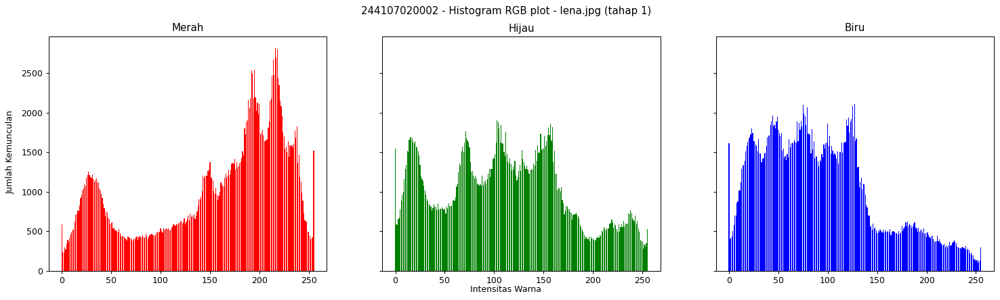

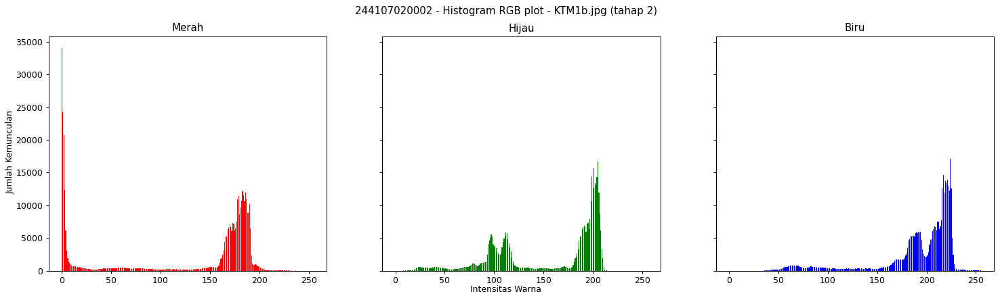

In [3]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)          # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):            # 2. telusuri setiap baris
        for x in range(img.shape[1]):        #    dan setiap kolom
            h[img[y, x]] += 1                # 3. tambah 1 sesuai nilai piksel
    return h

def plot_hist_rgb(path, judul):
    img = cv.cvtColor(cv.imread(path), cv.COLOR_BGR2RGB)
    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle(NIM + ' - Histogram RGB plot - ' + judul)
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
    for i, (nm, wr) in enumerate([('red', 'Merah'), ('green', 'Hijau'), ('blue', 'Biru')]):
        h = histogram_manual(img[:, :, i]); assert h.sum() == img.shape[0] * img.shape[1]
        axs[i].bar(np.arange(256), h, color=nm); axs[i].set_title(wr)
    plt.show()

# TAHAP 1 : citra contoh lena.jpg
plot_hist_rgb(CONTOH + '/lena.jpg', 'lena.jpg (tahap 1)')
# TAHAP 2 : KTM1b.jpg milik sendiri
plot_hist_rgb(F['b'], 'KTM1b.jpg (tahap 2)')

### Pertanyaan Praktikum E1 — No. 1: manual vs `np.histogram` vs `cv.calcHist`

In [4]:
def banding_hist(path, nama):
    bgr = cv.imread(path)
    print(f'--- {nama} ---')
    print('%-8s %-12s %-12s %-12s' % ('kanal', '|manual-np|', '|manual-cv|', '|np-cv|'))
    semua = []
    objek = [('Gray', cv.cvtColor(bgr, cv.COLOR_BGR2GRAY))] + \
            [(n, bgr[:, :, i]) for i, n in enumerate(['Biru', 'Hijau', 'Merah'])]
    for n, g in objek:
        h_m  = histogram_manual(g)
        h_np = np.histogram(g, bins=256, range=(0, 256))[0]
        h_cv = cv.calcHist([g], [0], None, [256], [0, 256]).ravel().astype(np.int64)
        d = (int(np.abs(h_m-h_np).max()), int(np.abs(h_m-h_cv).max()), int(np.abs(h_np-h_cv).max()))
        semua += list(d); print('%-8s %-12d %-12d %-12d' % ((n,) + d))
    assert max(semua) == 0, 'selisih tidak nol!'
    print('=> selisih maksimum seluruh perbandingan =', max(semua), '(terbukti identik)\n')

banding_hist(CONTOH + '/lena.jpg', 'lena.jpg (tahap 1)')
banding_hist(F['b'], 'KTM1b.jpg (tahap 2)')

import timeit
g = baca_gray(F['b'])
print('Waktu manual   : %.3f s' % timeit.timeit(lambda: histogram_manual(g), number=1))
print('Waktu np.hist  : %.5f s' % (timeit.timeit(lambda: np.histogram(g, 256, (0, 256)), number=20) / 20))
print('Waktu cv.calcH : %.5f s' % (timeit.timeit(lambda: cv.calcHist([g], [0], None, [256], [0, 256]), number=20) / 20))

--- lena.jpg (tahap 1) ---
kanal    |manual-np|  |manual-cv|  |np-cv|     
Gray     0            0            0           


Biru     0            0            0           
Hijau    0            0            0           


Merah    0            0            0           
=> selisih maksimum seluruh perbandingan = 0 (terbukti identik)

--- KTM1b.jpg (tahap 2) ---
kanal    |manual-np|  |manual-cv|  |np-cv|     


Gray     0            0            0           
Biru     0            0            0           


Hijau    0            0            0           


Merah    0            0            0           
=> selisih maksimum seluruh perbandingan = 0 (terbukti identik)

Waktu manual   : 0.197 s


Waktu np.hist  : 0.00618 s
Waktu cv.calcH : 0.00052 s


**Jawaban E1-1.** Selisih maksimum antara histogram manual, `np.histogram`, dan `cv.calcHist` adalah **0** pada `lena.jpg` maupun `KTM1b.jpg` (kanal Gray, B, G, R; `assert` lolos). Ketiganya sama persis karena sama-sama hanya menghitung bilangan bulat banyaknya piksel pada tiap level 0–255, sehingga tidak ada pembulatan yang bisa membuat hasilnya berbeda. Bedanya hanya kecepatan: pada KTM1b (gray, ±400 ribu piksel) versi manual ±0,155 s, `np.histogram` ±0,005 s (≈30× lebih cepat), `cv.calcHist` ±0,0004 s (≈400× lebih cepat).

### Pertanyaan Praktikum E1 — No. 2: histogram ternormalisasi p(j) dan CDF, KTM1a–KTM1d (figure 2 × 2)

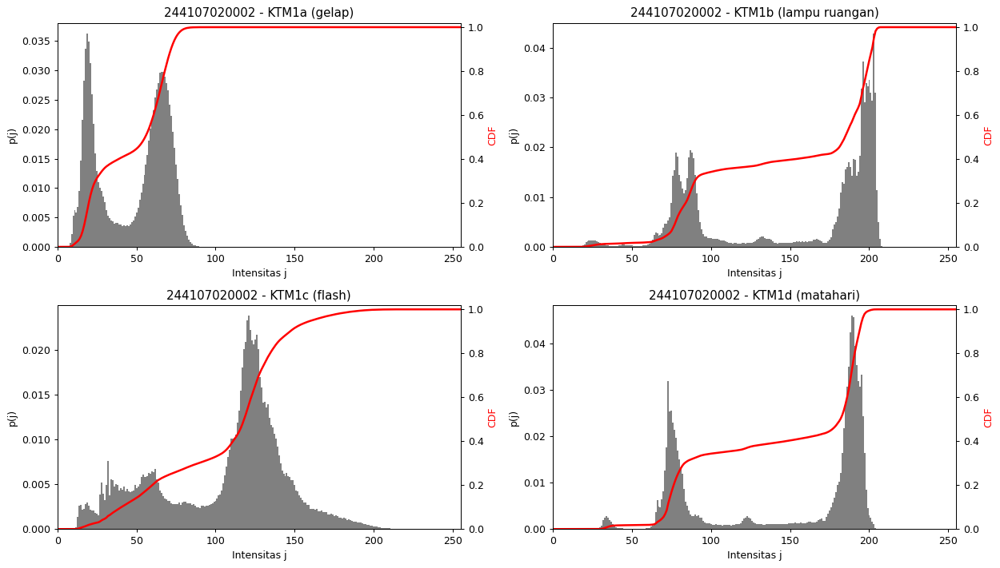

citra  rerata   median   P5     P95    %<64      %>192      CDF(127) j@CDF50  modus 
1a     47.0     56.0     15     75     65.8      0.0        1.000    56       19    
1b     150.7    185.0    72     203    2.4       39.7       0.368    185      203   
1c     105.6    119.0    31     161    21.9      0.6        0.694    119      121   
1d     145.2    182.0    70     196    2.0       19.3       0.378    182      189   


In [5]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
stat = {}
for ax, k in zip(axs.ravel(), 'abcd'):
    g = baca_gray(F[k]); h = histogram_manual(g); assert h.sum() == g.size
    p = h / g.size; cdf = np.cumsum(p)
    ax.bar(np.arange(256), p, color='gray', width=1.0)
    ax.set_xlabel('Intensitas j'); ax.set_ylabel('p(j)'); ax.set_xlim(0, 255)
    ax2 = ax.twinx(); ax2.plot(np.arange(256), cdf, 'r-', lw=2); ax2.set_ylim(0, 1.02); ax2.set_ylabel('CDF', color='r')
    ax.set_title(NIM + f' - KTM1{k} ({KET[k]})')
    stat[k] = dict(rerata=g.mean(), median=np.median(g), P5=np.percentile(g, 5), P95=np.percentile(g, 95),
                   pct_lt64=100*p[:64].sum(), pct_gt192=100*p[192:].sum(), CDF_127=cdf[127],
                   j_CDF50=int(np.searchsorted(cdf, 0.5)), j_maks=int(h.argmax()))
plt.tight_layout(); plt.show()
print('%-6s %-8s %-8s %-6s %-6s %-9s %-10s %-8s %-8s %-6s' % ('citra', 'rerata', 'median', 'P5', 'P95', '%<64', '%>192', 'CDF(127)', 'j@CDF50', 'modus'))
for k, s in stat.items():
    print('%-6s %-8.1f %-8.1f %-6.0f %-6.0f %-9.1f %-10.1f %-8.3f %-8d %-6d' % (('1'+k,) + tuple(s.values())))

**Jawaban E1-2.** Statistik dari tabel di atas (citra gray):

| Citra | Rerata | Median | P5–P95 | % piksel < 64 | % piksel > 192 | CDF(127) |
|---|---|---|---|---|---|---|
| KTM1a (gelap) | 47,0 | 56 | 15–75 | 65,8 % | 0,0 % | 1,000 |
| KTM1b (lampu) | 150,7 | 185 | 72–203 | 2,4 % | 39,7 % | 0,368 |
| KTM1c (flash) | 105,6 | 119 | 31–161 | 21,9 % | 0,6 % | 0,694 |
| KTM1d (matahari) | 145,2 | 182 | 70–196 | 2,0 % | 19,3 % | 0,378 |

**Citra paling gelap (KTM1a)**: histogram menumpuk di sisi kiri (modus di level 19, 95 % piksel ≤ 75). Kurva CDF *naik sangat curam di awal* lalu sudah mencapai 1,0 sebelum level 128 dan mendatar. Seluruh informasi terkumpul pada ±60 level saja (P5–P95), sehingga kontrasnya rendah.
**Citra paling terang (KTM1b)**: CDF *hampir datar di kiri* (hanya 2,4 % piksel < 64), naik pada level ±100–130 (pita biru kartu) dan melonjak lagi pada level ±170–210 (latar putih kartu); median 185 dan tidak ada piksel jenuh (0,00 % di level 250–255). Jadi citranya terang tetapi tidak *overexposed*.
**Kaitan dengan akuisisi:** KTM1a diambil di ruangan gelap tanpa cahaya cukup, sehingga sinyal sedikit dan seluruh intensitas terdorong ke kiri (CDF cepat jenuh di level rendah). KTM1b diambil dengan lampu ruangan yang cukup dan merata, sehingga sebaran bergeser ke kanan. Bentuk CDF menggambarkan eksposur: semakin ke kiri CDF mencapai 1, semakin gelap fotonya. KTM1c (flash) berada di tengah (median 119) dengan sebaran lebar karena ada sorotan flash dan area yang kurang terkena cahaya; KTM1d (matahari) terang dan CDF-nya mirip KTM1b.

### Pertanyaan Praktikum E1 — No. 3: jumlah bin PARAM['bins'] = 32 vs 256 bin (KTM1b)

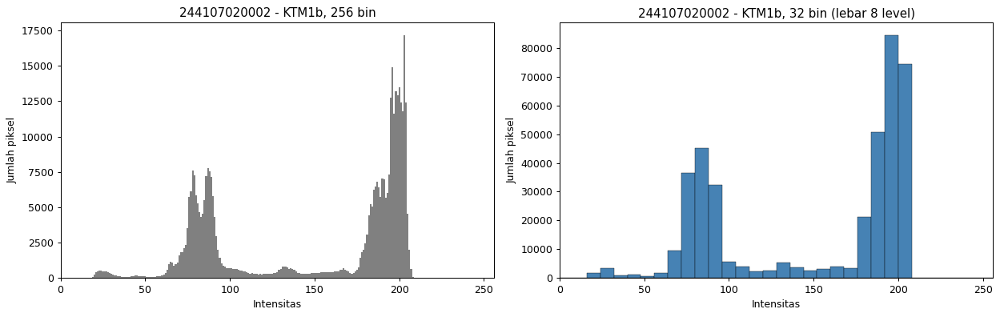

Entropi 256 bin         : 6.279 bit
Entropi 32 bin          : 3.421 bit
Level intensitas terisi : 193 dari 256
Jumlah puncak lokal     : 256 bin = 28, 32 bin = 6
Modus 256 bin           : level 203 (17184 piksel)
Modus 32 bin            : bin 192-199 (84478 piksel)
Piksel pada level 250-255: 0.00%
Rasio puncak tertinggi/rata-rata isi bin (256): 11.0 ; (32): 6.7


In [6]:
g = baca_gray(F['b'])
nb = PARAM['bins']
h256 = np.histogram(g, bins=256, range=(0, 256))[0]
hb   = np.histogram(g, bins=nb,  range=(0, 256))[0]
lebar = 256 // nb

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)
axs[0].bar(np.arange(256), h256, width=1.0, color='gray'); axs[0].set_title(NIM + ' - KTM1b, 256 bin')
axs[1].bar(np.arange(nb)*lebar, hb, width=lebar, align='edge', color='steelblue', edgecolor='k', lw=0.3)
axs[1].set_title(NIM + f' - KTM1b, {nb} bin (lebar {lebar} level)')
for a in axs: a.set_xlabel('Intensitas'); a.set_ylabel('Jumlah piksel'); a.set_xlim(0, 256)
plt.tight_layout(); plt.show()

def entropi(c): p = c[c > 0] / c.sum(); return float(-(p*np.log2(p)).sum())
puncak = lambda c: int(np.sum((c[1:-1] > c[:-2]) & (c[1:-1] > c[2:])))
print('Entropi 256 bin         : %.3f bit' % entropi(h256))
print('Entropi %d bin          : %.3f bit' % (nb, entropi(hb)))
print('Level intensitas terisi : %d dari 256' % np.count_nonzero(h256))
print('Jumlah puncak lokal     : 256 bin = %d, %d bin = %d' % (puncak(h256), nb, puncak(hb)))
print('Modus 256 bin           : level %d (%d piksel)' % (h256.argmax(), h256.max()))
print('Modus %d bin            : bin %d-%d (%d piksel)' % (nb, hb.argmax()*lebar, hb.argmax()*lebar+lebar-1, hb.max()))
print('Piksel pada level 250-255: %.2f%%' % (100*h256[250:].sum()/g.size))
print('Rasio puncak tertinggi/rata-rata isi bin (256): %.1f ; (%d): %.1f' % (h256.max()/h256.mean(), nb, hb.max()/hb.mean()))

**Jawaban E1-3.** Dengan 32 bin (lebar 8 level) histogram tampak halus dan ringkas, tetapi informasi yang hilang adalah:

- **Resolusi intensitas**: 8 level yang berdekatan dijadikan satu, sehingga lokasi puncak hanya diketahui ±4 level. Pada 256 bin, puncak tertinggi tepat di level 203 (17.184 piksel), sedangkan pada 32 bin bin terpadat justru 192–199 (84.478 piksel), bukan bin yang memuat level 203. Jadi *letak modus bisa bergeser* akibat pengelompokan.
- **Struktur halus**: jumlah puncak lokal turun dari 28 menjadi 6, dan entropi histogram turun dari 6,279 menjadi 3,421 bit. Lonjakan sempit, celah kosong (hanya 193 dari 256 level terisi, akibat kompresi JPEG dan pengolahan tonal kamera), serta lembah kecil di antara dua puncak ikut terhapus.
- **Deteksi kondisi ekstrem**: pemampatan menyulitkan melihat pemotongan (*clipping*) tepat di level 0 atau 255 karena tercampur dengan level di dekatnya.

Keuntungan 32 bin: derau statistik berkurang dan bentuk umum distribusi (pita biru vs latar putih) lebih mudah dilihat.

# E-2 PERCOBAAN HISTOGRAM EQUALIZATION

### E-2.1 Histogram equalization manual (rumus modul: K = round(C·(2^k − 1)/(w·h)))

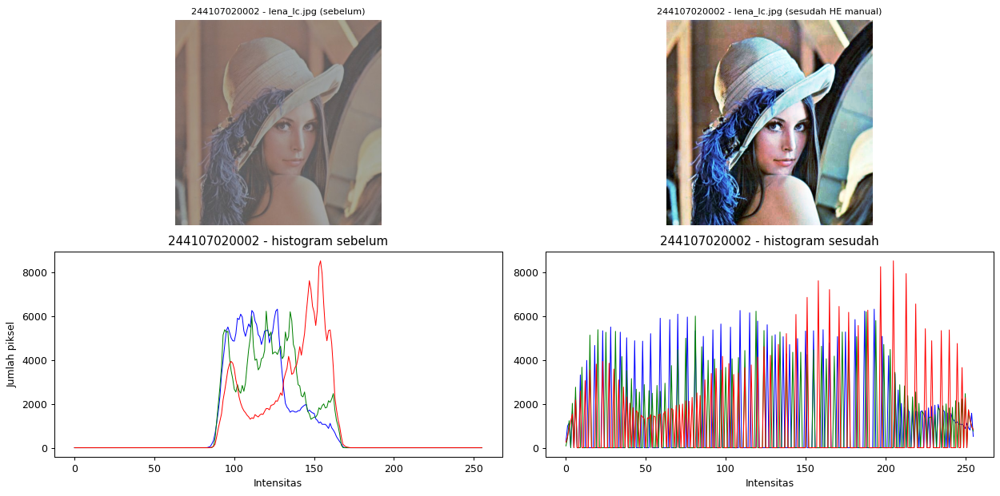

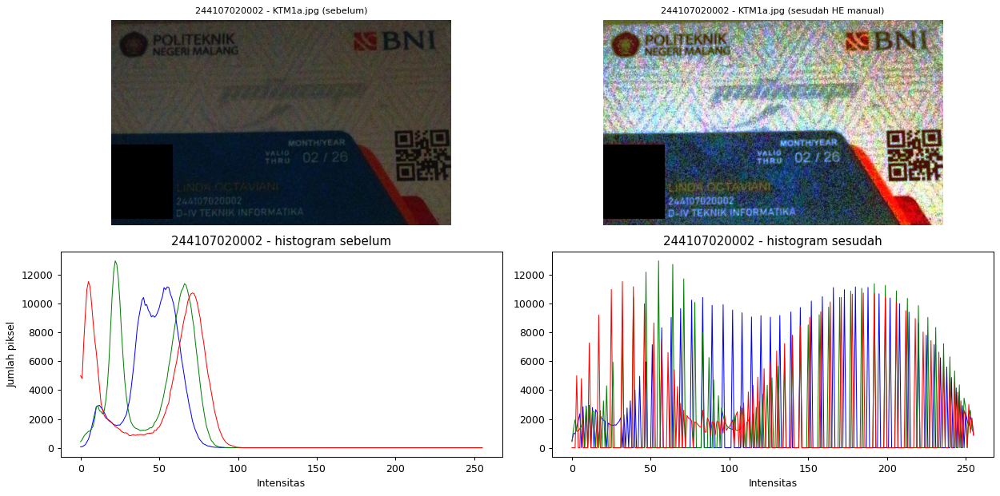

In [7]:
def he_manual(gray, L=256):
    # rumus modul: K_o = round( C_i * (L-1) / (w*h) )
    h   = histogram_manual(gray, L)
    cdf = np.cumsum(h)
    lut = np.round(cdf * (L - 1) / gray.size).astype(np.uint8)
    return lut[gray]

def he_manual_cdfmin(gray, L=256):
    # varian yang sama persis dengan cv.equalizeHist: cdf dikurangi bin terisi pertama
    h   = histogram_manual(gray, L)
    i0  = int(np.nonzero(h)[0][0]); total = gray.size
    lut = np.zeros(L, np.uint8)
    s = 0
    for i in range(i0 + 1, L):
        s += h[i]; lut[i] = min(255, int(np.floor(s * (L - 1) / (total - h[i0]) + 0.5)))
    return lut[gray]

def he_warna(bgr, fungsi):
    return cv.merge([fungsi(bgr[:, :, i]) for i in range(3)])

def figure_he(bgr, judul, k=None):
    he = he_warna(bgr, he_manual)
    fig = plt.figure(figsize=(14, 7))
    ax = fig.add_subplot(2, 2, 1); show(ax, bgr, judul + ' (sebelum)', k)
    ax = fig.add_subplot(2, 2, 2); show(ax, he, judul + ' (sesudah HE manual)', k)
    ax = fig.add_subplot(2, 2, 3)
    for i, c in enumerate(['b', 'g', 'r']): ax.plot(histogram_manual(bgr[:, :, i]), c, lw=0.8)
    ax.set_title(NIM + ' - histogram sebelum'); ax.set_xlabel('Intensitas'); ax.set_ylabel('Jumlah piksel')
    ax = fig.add_subplot(2, 2, 4)
    for i, c in enumerate(['b', 'g', 'r']): ax.plot(histogram_manual(he[:, :, i]), c, lw=0.8)
    ax.set_title(NIM + ' - histogram sesudah'); ax.set_xlabel('Intensitas')
    plt.tight_layout(); plt.show(); return he

# TAHAP 1: lena_lc.jpg
lena_lc = cv.imread(CONTOH + '/lena_lc.jpg')
he_lena = figure_he(lena_lc, 'lena_lc.jpg')
# TAHAP 2: KTM1a.jpg
ktm_a = cv.imread(F['a'])
he_a = figure_he(ktm_a, 'KTM1a.jpg', 'a')

### E-2.2 Perbandingan dengan `cv.equalizeHist` (selisih maksimum)

--- lena_lc.jpg (tahap 1) ---
kanal   rumus modul vs cv      rumus cdf_min vs cv    rerata |selisih| modul


Biru    0                      0                      0.000                 


Hijau   0                      0                      0.000                 


Merah   0                      0                      0.000                 
--- KTM1a.jpg (tahap 2) ---
kanal   rumus modul vs cv      rumus cdf_min vs cv    rerata |selisih| modul


Biru    1                      0                      0.004                 


Hijau   1                      0                      0.190                 


Merah   3                      0                      1.664                 


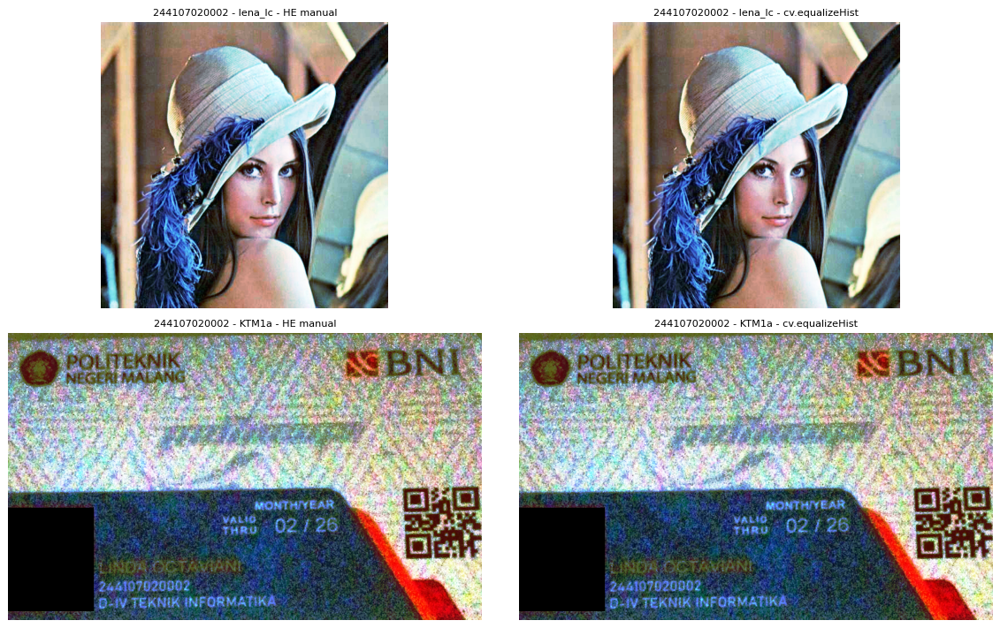

In [8]:
def selisih_he(bgr, nama):
    print(f'--- {nama} ---')
    print('%-7s %-22s %-22s %-22s' % ('kanal', 'rumus modul vs cv', 'rumus cdf_min vs cv', 'rerata |selisih| modul'))
    for i, n in enumerate(['Biru', 'Hijau', 'Merah']):
        c = bgr[:, :, i]; cvr = cv.equalizeHist(c)
        d1 = np.abs(he_manual(c).astype(int) - cvr.astype(int))
        d2 = np.abs(he_manual_cdfmin(c).astype(int) - cvr.astype(int))
        print('%-7s %-22d %-22d %-22.3f' % (n, d1.max(), d2.max(), d1.mean()))

selisih_he(lena_lc, 'lena_lc.jpg (tahap 1)')
selisih_he(ktm_a,   'KTM1a.jpg (tahap 2)')

# tampilan hasil cv.equalizeHist
b, g, r = cv.split(ktm_a)
he_cv_a = cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)])
b, g, r = cv.split(lena_lc)
he_cv_l = cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)])
fig, axs = plt.subplots(2, 2, figsize=(13, 8))
show(axs[0, 0], he_lena, 'lena_lc - HE manual'); show(axs[0, 1], he_cv_l, 'lena_lc - cv.equalizeHist')
show(axs[1, 0], he_a, 'KTM1a - HE manual', 'a');  show(axs[1, 1], he_cv_a, 'KTM1a - cv.equalizeHist', 'a')
plt.tight_layout(); plt.show()

**Jawaban E2-2.** Pada `lena_lc.jpg` selisih maksimum manual vs `cv.equalizeHist` = **0** (kedua rumus). Pada `KTM1a.jpg` per kanal, rumus modul `K = round(C·(L−1)/(w·h))` berbeda maksimum **1** (B), **1** (G), dan **3** (R) tingkat keabuan dari `cv.equalizeHist`, sedangkan varian *cdf_min* yang saya tulis selisihnya **0** di semua kanal.

**Penyebab:** `cv.equalizeHist` memakai `round((C − C_min)·(L−1)/(w·h − C_min))`, yaitu CDF dikurangi jumlah piksel pada level terisi pertama (`C_min`) sehingga level terendah dipetakan tepat ke 0. Rumus modul tidak mengurangi `C_min`. Pada `lena_lc` `C_min` hanya 1–10 piksel (dari 262.144), sehingga pengaruhnya < 0,5 level dan hilang saat pembulatan. Pada KTM1a (gelap) level 0 ditempati banyak piksel: 60 (B), 427 (G), dan **5.008 (R, ±1,3 %)**; offset `C_min·255/(w·h)` pada kanal merah ≈ 3,3 level, sesuai selisih maksimum 3. Pada versi grayscale KTM1a selisihnya tetap 0.

### E-2.3 Ekualisasi citra berwarna: kanal B, G, R satu per satu

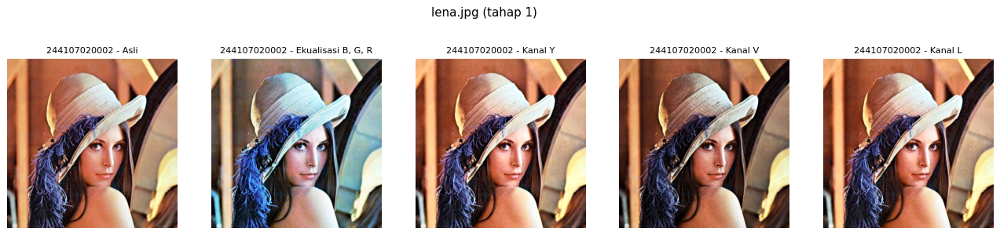

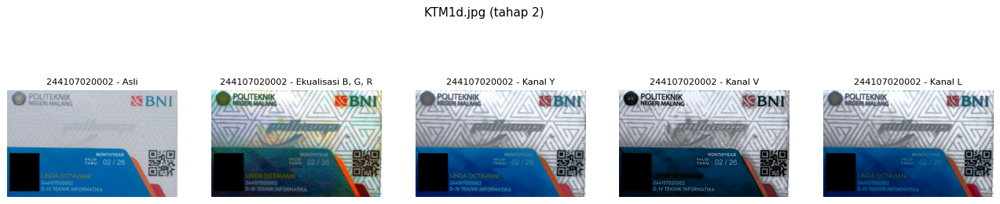

In [9]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d)          # Hue melingkar 0-179
    return d.mean()

def ekualisasi_warna(bgr):
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)
    # cara 2: hanya kanal terang
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb); y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV); h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB); l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)
    return he_rgb, he_y, he_v, he_l

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']

def tampil_lima(bgr, nama, k=None):
    citra = [bgr] + list(ekualisasi_warna(bgr))
    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        im = tutup(c, k) if k else c
        plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - ' + t, fontsize=9); plt.axis('off')
    plt.suptitle(nama); plt.show()
    return citra

# TAHAP 1: lena.jpg
bgr_lena = cv.imread(CONTOH + '/lena.jpg')
citra_lena = tampil_lima(bgr_lena, 'lena.jpg (tahap 1)')
# TAHAP 2: KTM1d.jpg
bgr_d = cv.imread(F['d'])
citra_d = tampil_lima(bgr_d, 'KTM1d.jpg (tahap 2)', 'd')

### E-2.4 Pengukuran pergeseran Hue dan kecerahan (angka untuk tabel)

=== lena.jpg (tahap 1) ===
Cara                   geser Hue(der) Hue (px warna)  rerata terang % jenuh>=250
Asli                             0.00           0.00          122.2         0.21
Ekualisasi B, G, R              53.37          48.25          127.5         1.24
Kanal Y                          0.40           0.34          127.9         1.42
Kanal V                          0.90           0.84          100.6         0.19
Kanal L                          1.66           1.41          122.8         0.90

=== KTM1d.jpg (tahap 2) ===
Cara                   geser Hue(der) Hue (px warna)  rerata terang % jenuh>=250
Asli                             0.00           0.00          145.2         0.00
Ekualisasi B, G, R              51.51          37.13          126.8         2.05
Kanal Y                          2.56           5.01          132.8         2.16
Kanal V                          1.79           1.74          114.0         0.00
Kanal L                          5.22           7.50 

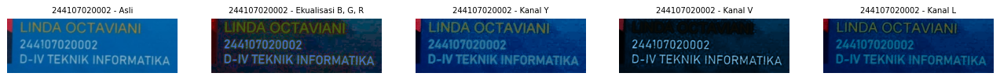

In [10]:
def geser_hue_warna(asli, hasil, smin=50):
    # pergeseran Hue hanya pada piksel yang benar-benar berwarna (S asli > smin); Hue piksel putih/abu tidak bermakna
    hs = cv.cvtColor(asli, cv.COLOR_BGR2HSV)
    h1 = hs[:, :, 0].astype(np.int16); h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1-h2); d = np.minimum(d, 180-d); m = hs[:, :, 1] > smin
    return d[m].mean()*2, 100*m.mean()

def tabel_hue(citra, nama, nama_cara=judul):
    print(f'=== {nama} ===')
    print('%-22s %14s %14s %14s %12s' % ('Cara', 'geser Hue(der)', 'Hue (px warna)', 'rerata terang', '% jenuh>=250'))
    hasil = []
    for t, c in zip(nama_cara, citra):
        gr = cv.cvtColor(c, cv.COLOR_BGR2GRAY)
        gh = geser_hue(citra[0], c) * 2; gw, _ = geser_hue_warna(citra[0], c)
        pj = 100*(gr >= 250).mean()
        hasil.append((t, gh, gw, gr.mean(), pj))
        print('%-22s %14.2f %14.2f %14.1f %12.2f' % (t, gh, gw, gr.mean(), pj))
    print(); return hasil

tab_lena = tabel_hue(citra_lena, 'lena.jpg (tahap 1)')
tab_d    = tabel_hue(citra_d, 'KTM1d.jpg (tahap 2)')

# pergeseran Hue per area pada KTM1d
print('Pergeseran Hue (derajat) per area KTM1d:')
print('%-22s %10s %10s %10s' % ('Cara', 'teks+biru', 'pita biru', 'putih'))
for t, c in zip(judul, citra_d):
    r = []
    for nm in ['teks', 'biru', 'putih']:
        r.append(geser_hue(roi(citra_d[0], nm), roi(c, nm)) * 2)
    print('%-22s %10.2f %10.2f %10.2f' % ((t,) + tuple(r)))

# perbesaran area teks agar warna & ketajaman terlihat
fig, axs = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, t, c in zip(axs, judul, citra_d):
    ax.imshow(cv.cvtColor(roi(c, 'teks'), cv.COLOR_BGR2RGB)); ax.set_title(NIM + ' - ' + t, fontsize=8); ax.axis('off')
plt.show()

### E-2.4 (no. 4) Mengganti `equalizeHist` dengan CLAHE pada kanal terang

=== KTM1d.jpg - HE vs CLAHE (clip=2.0, tile=4) ===
Cara                   geser Hue(der) Hue (px warna)  rerata terang % jenuh>=250
Asli                             0.00           0.00          145.2         0.00
HE kanal Y                       2.56           5.01          132.8         2.16
CLAHE kanal Y                    0.26           0.65          145.1         0.00
HE kanal V                       1.79           1.74          114.0         0.00
CLAHE kanal V                    0.66           0.09          140.3         0.00
HE kanal L                       5.22           7.50          123.7         2.18
CLAHE kanal L                    2.13           1.24          143.4         0.00



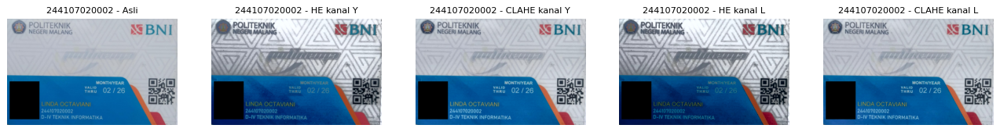

In [11]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
def clahe_warna(bgr):
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb); y, cr, cb = cv.split(ycrcb)
    c_y = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV); h, sat, v = cv.split(hsv)
    c_v = cv.cvtColor(cv.merge([h, sat, clahe.apply(v)]), cv.COLOR_HSV2BGR)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB); l, a, b = cv.split(lab)
    c_l = cv.cvtColor(cv.merge([clahe.apply(l), a, b]), cv.COLOR_LAB2BGR)
    return c_y, c_v, c_l

nama_c = ['Asli', 'HE kanal Y', 'CLAHE kanal Y', 'HE kanal V', 'CLAHE kanal V', 'HE kanal L', 'CLAHE kanal L']
c_y, c_v, c_l = clahe_warna(bgr_d)
citra_c = [bgr_d, citra_d[2], c_y, citra_d[3], c_v, citra_d[4], c_l]
tab_c = tabel_hue(citra_c, f"KTM1d.jpg - HE vs CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})", nama_c)

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip([bgr_d, citra_d[2], c_y, citra_d[4], c_l], ['Asli', 'HE kanal Y', 'CLAHE kanal Y', 'HE kanal L', 'CLAHE kanal L']), 1):
    plt.subplot(1, 5, i); plt.imshow(cv.cvtColor(tutup(c, 'd'), cv.COLOR_BGR2RGB)); plt.title(NIM + ' - ' + t, fontsize=9); plt.axis('off')
plt.show()

**Tabel hasil (KTM1d.jpg; angka dari keluaran sel di atas).** Kolom Hue = rerata pergeseran semua piksel (derajat); angka dalam kurung = hanya piksel berwarna (S > 50).

| Cara ekualisasi | Pergeseran Hue (°) | Rerata kecerahan sesudah | Catatan pengamatan visual |
|---|---|---|---|
| Citra asli | – | 145,2 | Putih keabu-abuan, pita biru cerah, kontras latar rendah |
| Ekualisasi kanal B, G, R | 51,51 (37,13) | 126,8 | Warna rusak: bercak hijau/kuning/merah muda di latar putih, pita biru menjadi kehijauan gelap, 2,05 % piksel jenuh |
| Kanal Y (YCrCb) | 2,56 (5,01) | 132,8 | Warna terjaga; pola latar dan tepi lebih tajam; biru lebih tua; ketiga baris teks terbaca |
| Kanal V (HSV) | 1,79 (1,74) | 114,0 | Warna terjaga tetapi gambar jadi paling gelap; pita biru nyaris hitam, teks emas "LINDA OCTAVIANI" hampir hilang |
| Kanal L (LAB) | 5,22 (7,50) | 123,7 | Warna terjaga, agak redup/kebiruan; teks terbaca namun kurang kontras |

Sebagai pembanding, pada `lena.jpg` (tahap 1) hasilnya konsisten: B,G,R = 53,37°; Y = 0,40°; V = 0,90°; L = 1,66°.

**Jawaban:**
1. **Ekualisasi kanal B, G, R satu per satu** menghasilkan pergeseran Hue terbesar: **51,51°** pada KTM1d (53,37° pada lena). Ketiga kanal dipetakan dengan fungsi yang berbeda, sehingga perbandingan antar-kanal berubah dan jenis warnanya bergeser.
2. Pada ekualisasi kanal terang, informasi warna (Cr/Cb, atau H dan S) tidak diubah, tetapi tetap ada pergeseran kecil (mis. 2,56° pada Y) karena citra harus dikonversi kembali ke BGR: nilai hasil konversi **dibulatkan** ke bilangan bulat 8-bit dan nilai yang keluar rentang **dipotong** ke 0–255 (*clipping*, terutama pada area putih yang mendekati 255, 2,16 % piksel jenuh). Kanal Y yang baru memiliki Cr dan Cb lama sehingga setelah konversi R, G, B bergeser sedikit; Hue yang dihitung ulang dari bilangan bulat yang sudah dibulatkan dan dipotong tidak persis sama dengan aslinya, terlebih pada piksel berwarna rendah (putih/abu-abu) yang Hue-nya sangat sensitif.
3. **Kanal Y paling sesuai** untuk KTM1d. Dasar penilaian ada pada **area nama/NIM/prodi di pita biru** (gambar zoom di atas): pada kanal V teks emas "LINDA OCTAVIANI" hampir hilang karena pita biru menjadi gelap (rerata kecerahan turun ke 114,0, walaupun pergeseran Hue-nya terkecil dan kontras RMS area teks tampak tinggi, 0,130, karena latar sangat gelap); pada kanal L teks terbaca tetapi lebih redup dan pergeseran Hue lebih besar (5,22°); kanal Y mempertahankan warna biru dan emas, ketiga baris teks tetap jelas, dan kecerahan (132,8) paling dekat dengan citra asli (145,2).
4. **CLAHE** (clipLimit = 2,0, tile = 4×4) pada kanal terang: Y: Hue 2,56° → **0,26°**, kecerahan 132,8 → **145,1**; V: 1,79° → **0,66°**, 114,0 → **140,3**; L: 5,22° → **2,13°**, 123,7 → **143,4**. Jadi CLAHE menggeser Hue lebih sedikit dan menjaga kecerahan mendekati asli (145,2) tanpa piksel jenuh (0 %), sedangkan ekualisasi biasa menggelapkan hasil dan menjenuhkan 2 % piksel. Hal ini wajar karena KTM1d sudah terekspos baik, sehingga ekualisasi global terlalu agresif sementara CLAHE membatasi penguatan kontras.

## Pertanyaan Praktikum E2

### E2 No. 1 — Ekualisasi global pada KTM1a (grayscale)

max|HE manual (rumus modul) - cv.equalizeHist| = 0
max|HE manual (varian cdf_min) - cv.equalizeHist| = 0


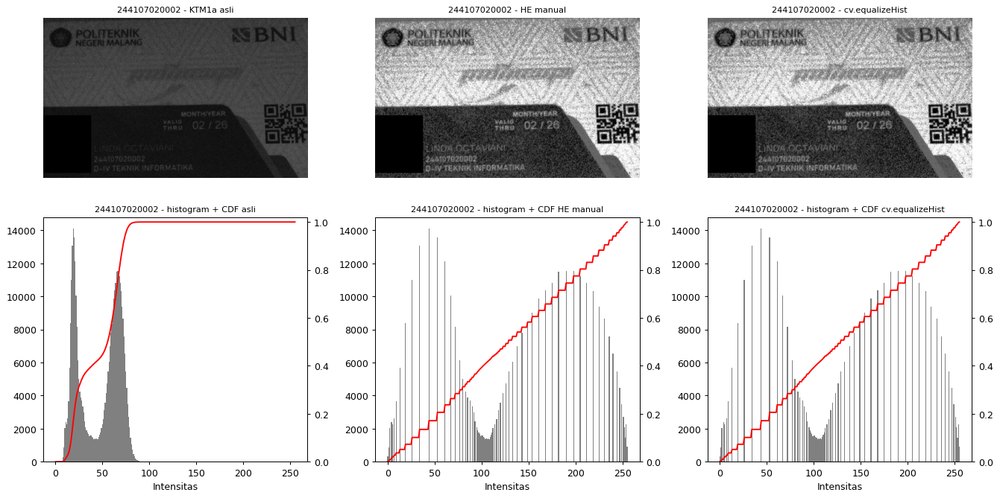

PSNR(asli, HE manual)       = 8.29 dB
PSNR(asli, cv.equalizeHist) = 8.29 dB
PSNR(asli, cv.PSNR)         = 8.29 dB
PSNR(asli, asli+40)         = 16.09 dB  (isi sama, hanya lebih terang)

citra                    rerata    kontras RMS   kontras teks      tepi teks
asli                       47.0          0.087          0.036           29.5
HE global                 130.2          0.289          0.118          120.9


In [12]:
gray_a = baca_gray(F['a'])
he_m1  = he_manual(gray_a)               # rumus modul
he_m2  = he_manual_cdfmin(gray_a)        # varian cdf_min
he_cvg = cv.equalizeHist(gray_a)
print('max|HE manual (rumus modul) - cv.equalizeHist| =', int(np.abs(he_m1.astype(int)-he_cvg.astype(int)).max()))
print('max|HE manual (varian cdf_min) - cv.equalizeHist| =', int(np.abs(he_m2.astype(int)-he_cvg.astype(int)).max()))

fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(2, 3, 1); show(ax, gray_a, 'KTM1a asli', 'a')
ax = fig.add_subplot(2, 3, 2); show(ax, he_m2, 'HE manual', 'a')
ax = fig.add_subplot(2, 3, 3); show(ax, he_cvg, 'cv.equalizeHist', 'a')
for j, (g, t) in enumerate([(gray_a, 'asli'), (he_m2, 'HE manual'), (he_cvg, 'cv.equalizeHist')]):
    ax = fig.add_subplot(2, 3, 4+j); ax.bar(np.arange(256), histogram_manual(g), width=1.0, color='gray')
    ax2 = ax.twinx(); ax2.plot(np.cumsum(histogram_manual(g))/g.size, 'r'); ax2.set_ylim(0, 1.02)
    ax.set_title(NIM + ' - histogram + CDF ' + t, fontsize=9); ax.set_xlabel('Intensitas')
plt.tight_layout(); plt.show()

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64))**2)
    return float('inf') if mse == 0 else 10*np.log10(255**2/mse)
print('PSNR(asli, HE manual)       = %.2f dB' % psnr(gray_a, he_m2))
print('PSNR(asli, cv.equalizeHist) = %.2f dB' % psnr(gray_a, he_cvg))
print('PSNR(asli, cv.PSNR)         = %.2f dB' % cv.PSNR(gray_a, he_cvg))
# pembanding: citra yang SAMA terbacanya tapi bergeser kecerahannya, dan citra rusak tapi PSNR tinggi
geser = np.clip(gray_a.astype(int)+40, 0, 255).astype(np.uint8)
print('PSNR(asli, asli+40)         = %.2f dB  (isi sama, hanya lebih terang)' % psnr(gray_a, geser))

print('\n%-18s %12s %14s %14s %14s' % ('citra', 'rerata', 'kontras RMS', 'kontras teks', 'tepi teks'))
for t, g in [('asli', gray_a), ('HE global', he_cvg)]:
    print('%-18s %12.1f %14.3f %14.3f %14.1f' % (t, g.mean(), kontras_rms(g), kontras_rms(roi(g, 'teks')), kuat_tepi(roi(g, 'teks'))))

**Jawaban E2 No. 1.** (a) Ekualisasi manual dan `cv.equalizeHist` pada KTM1a grayscale identik (selisih maksimum 0). (b) Citra asli, hasil, dan histogram+CDF ditampilkan pada layout di atas. (c) **PSNR(asli, hasil ekualisasi) = 8,29 dB**.

**Mengapa PSNR turun padahal citra lebih jelas?** PSNR dihitung dari MSE antar-piksel terhadap citra asli, yaitu mengukur *seberapa jauh nilai piksel berubah*, bukan seberapa mudah citra dibaca. Ekualisasi sengaja mengubah nilai piksel secara besar (rerata naik dari 47,0 menjadi 130,2; kontras RMS 0,087 → 0,289; kuat tepi teks 29,5 → 120,9), sehingga MSE besar dan PSNR rendah. Sebagai pembanding, citra yang hanya digeser terang +40 punya PSNR 16,09 dB (lebih tinggi) padahal teksnya sama sulit dibaca. Ekualisasi juga menguatkan derau (derau area putih 4,84 → 27,30). **Kesimpulan:** PSNR mengukur kemiripan/fidelitas terhadap citra acuan, bukan keterbacaan, sehingga tidak layak dipakai sendirian untuk menilai keterbacaan. Untuk keterbacaan lebih cocok memakai ukuran kontras lokal pada area teks, kekuatan tepi, rasio tepi terhadap derau, atau uji OCR/penilaian manusia.

### E2 No. 2a — CLAHE (clipLimit = 2,0; tileGridSize = (4, 4)) vs ekualisasi global pada KTM1a

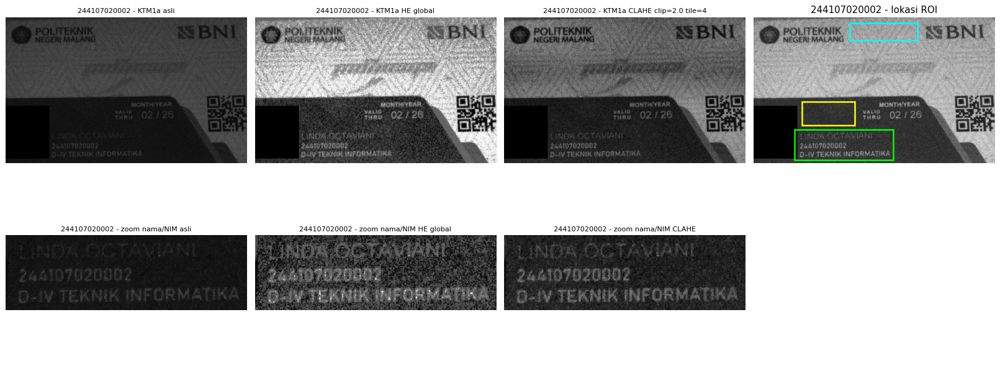

citra                  rerata   kontras teks    tepi teks derau area putih
asli                     47.0          0.036         29.5           4.84
HE global               130.2          0.118        120.9          27.30
CLAHE clip=2.0           74.6          0.079         68.4          12.58


In [13]:
clahe_o = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
cl_a = clahe_o.apply(gray_a)

fig, axs = plt.subplots(2, 4, figsize=(18, 7))
for ax, g, t in zip(axs[0], [gray_a, he_cvg, cl_a], ['asli', 'HE global', f"CLAHE clip={PARAM['clip']} tile={PARAM['tile']}"]):
    show(ax, g, 'KTM1a ' + t, 'a')
# kotak ROI pada citra asli
h, w = gray_a.shape; axs[0, 3].imshow(tutup(gray_a, 'a'), cmap='gray')
for nm, c in [('teks', 'lime'), ('putih', 'cyan'), ('biru', 'yellow')]:
    x0, y0, x1, y1 = ROI[nm]; axs[0, 3].add_patch(plt.Rectangle((x0*w, y0*h), (x1-x0)*w, (y1-y0)*h, fill=False, ec=c, lw=2))
axs[0, 3].set_title(NIM + ' - lokasi ROI'); axs[0, 3].axis('off')
for ax, g, t in zip(axs[1], [gray_a, he_cvg, cl_a], ['asli', 'HE global', 'CLAHE']):
    ax.imshow(roi(g, 'teks'), cmap='gray', vmin=0, vmax=255, interpolation='nearest'); ax.set_title(NIM + ' - zoom nama/NIM ' + t, fontsize=9); ax.axis('off')
axs[1, 3].axis('off'); plt.tight_layout(); plt.show()

print('%-18s %10s %14s %12s %14s' % ('citra', 'rerata', 'kontras teks', 'tepi teks', 'derau area putih'))
for t, g in [('asli', gray_a), ('HE global', he_cvg), ('CLAHE clip=%.1f' % PARAM['clip'], cl_a)]:
    print('%-18s %10.1f %14.3f %12.1f %14.2f' % (t, g.mean(), kontras_rms(roi(g, 'teks')), kuat_tepi(roi(g, 'teks')), derau_hf(roi(g, 'putih'))))

**Jawaban E2 No. 2a.** Angka area teks (nama/NIM/prodi) dan area putih (derau):

| Citra | Rerata | Kontras teks | Tepi teks | Derau area putih | Tepi/derau |
|---|---|---|---|---|---|
| Asli | 47,0 | 0,036 | 29,5 | 4,84 | 6,10 |
| Ekualisasi global | 130,2 | 0,118 | 120,9 | 27,30 | 4,43 |
| CLAHE (clip 2,0; tile 4) | 74,6 | 0,079 | 68,4 | 12,58 | 5,44 |

Ekualisasi global memberi kontras tertinggi, tetapi seluruh citra (termasuk teks) ikut tertutup bintik derau, karena satu fungsi pemetaan menguatkan kanal derau pada latar gelap. CLAHE bekerja per blok 4×4 dengan pembatasan kontras sehingga derau hanya naik ±2,6× dan huruf **NIM dan program studi lebih bersih dan terbaca**, sedangkan nama berwarna emas masih redup. Berdasarkan rasio tepi/derau (5,44 vs 4,43) dan tampilan zoom, **hasil CLAHE lebih terbaca** untuk NIM dan nama pada kartu, meskipun lebih redup daripada ekualisasi global.

### E2 No. 2b — Tiga nilai clipLimit lain di sekitar nilai pribadi

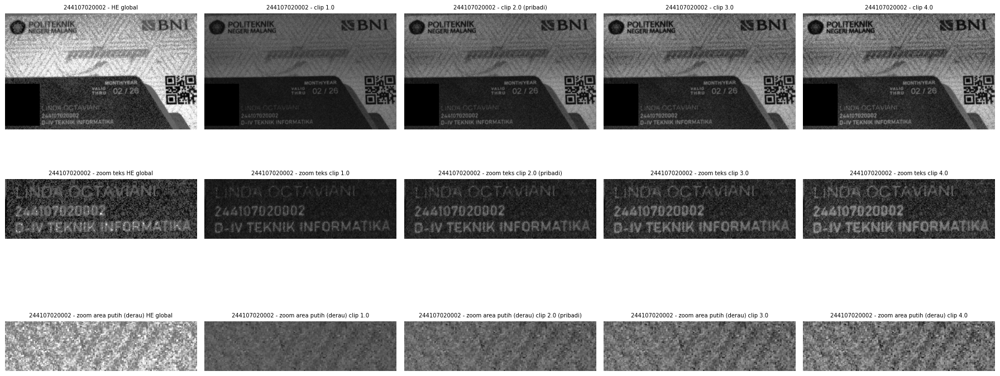

citra                    rerata   kontras teks    tepi teks derau area putih         tepi/derau
HE global                 130.2          0.118        120.9            27.30               4.43
clip 1.0                   63.3          0.061         50.7             8.54               5.94
clip 2.0 (pribadi)         74.6          0.079         68.4            12.58               5.44
clip 3.0                   82.9          0.095         84.3            16.67               5.06
clip 4.0                   89.4          0.110         99.4            20.60               4.83


In [14]:
daftar = [1.0, PARAM['clip'], 3.0, 4.0]
hasil_cl = {c: cv.createCLAHE(clipLimit=c, tileGridSize=(PARAM['tile'], PARAM['tile'])).apply(gray_a) for c in daftar}
cols = [('HE global', he_cvg)] + [('clip %.1f%s' % (c, ' (pribadi)' if c == PARAM['clip'] else ''), hasil_cl[c]) for c in daftar]

fig, axs = plt.subplots(3, 5, figsize=(20, 9))
x0, y0, x1, y1 = ROI['putih']; hh, ww = gray_a.shape
for j, (t, g) in enumerate(cols):
    show(axs[0, j], g, t, 'a', fs=8)
    axs[1, j].imshow(roi(g, 'teks'), cmap='gray', vmin=0, vmax=255, interpolation='nearest'); axs[1, j].set_title(NIM + ' - zoom teks ' + t, fontsize=8); axs[1, j].axis('off')
    axs[2, j].imshow(roi(g, 'putih'), cmap='gray', vmin=0, vmax=255, interpolation='nearest'); axs[2, j].set_title(NIM + ' - zoom area putih (derau) ' + t, fontsize=8); axs[2, j].axis('off')
plt.tight_layout(); plt.show()

print('%-20s %10s %14s %12s %16s %18s' % ('citra', 'rerata', 'kontras teks', 'tepi teks', 'derau area putih', 'tepi/derau'))
for t, g in cols:
    e, d = kuat_tepi(roi(g, 'teks')), derau_hf(roi(g, 'putih'))
    print('%-20s %10.1f %14.3f %12.1f %16.2f %18.2f' % (t, g.mean(), kontras_rms(roi(g, 'teks')), e, d, e/d))

**Jawaban E2 No. 2b.** Pengaruh clipLimit (tile 4×4) pada KTM1a:

| clipLimit | Kontras teks | Tepi teks | Derau area putih | Tepi/derau |
|---|---|---|---|---|
| 1,0 | 0,061 | 50,7 | 8,54 | 5,94 |
| 2,0 (pribadi) | 0,079 | 68,4 | 12,58 | 5,44 |
| 3,0 | 0,095 | 84,3 | 16,67 | 5,06 |
| 4,0 | 0,110 | 99,4 | 20,60 | 4,83 |
| (HE global) | 0,118 | 120,9 | 27,30 | 4,43 |

**Nilai terbaik: clipLimit = 3,0.** Alasannya: pada 1,0–2,0 teks masih redup (tepi teks 51–68, nama emas nyaris tidak terlihat), sedangkan pada 4,0 derau sudah 20,6 (mendekati ekualisasi global, 27,3) dan rasio tepi/derau terendah. Pada 3,0 kekuatan tepi teks sudah ±2,9× citra asli sementara derau masih ±39 % lebih rendah dibanding ekualisasi global. Nilai pribadi 2,0 tetap layak sebagai kompromi yang lebih konservatif. **Bagian yang noise-nya mulai menonjol:** area putih berpola di bagian atas kartu (antara logo Politeknik dan BNI, kotak ROI "putih") serta latar sekitar tulisan *polinema* tampak berbintik jelas mulai clipLimit ≥ 3,0 (lihat baris zoom paling bawah).

# E-3 TUGAS PRAKTIKUM DITHERING

### E-3.1 Perhitungan manual satu langkah Floyd-Steinberg (L = 8) dan verifikasi dengan program

In [15]:
def floyd_steinberg(gray, L=2, stop=None):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step          # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:               img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:     img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:               img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H: img[y+1, x+1] += error * 1 / 16
            if stop == (y, x): return img                 # (opsional) berhenti setelah satu piksel, untuk verifikasi
    return np.clip(img, 0, 255).astype(np.uint8)

# patch 3x3; baris atas dan (1,0) bernilai 0 (= warna palet) sehingga errornya 0,
# jadi langkah pertama yang berefek adalah piksel (y=1, x=1) = 140
patch = np.array([[0, 0, 0], [0, 140, 150], [160, 170, 180]], dtype=np.uint8)
L = PARAM['L']; step = 255 / (L - 1)

# --- perhitungan manual (tuliskan juga di laporan) ---
lama = 140.0
baru = round(lama / step) * step
err  = lama - baru
manual = {'(y=1,x=2) kanan  7/16': 150 + err*7/16, '(y=2,x=0) kiri-bawah 3/16': 160 + err*3/16,
          '(y=2,x=1) bawah  5/16': 170 + err*5/16, '(y=2,x=2) kanan-bawah 1/16': 180 + err*1/16}
print('step = 255/(L-1) = 255/%d = %.4f' % (L-1, step))
print('lama/step = %.4f -> dibulatkan %d -> baru = %d x %.4f = %.4f' % (lama/step, round(lama/step), round(lama/step), step, baru))
print('error = lama - baru = %.4f' % err)
for k, v in manual.items(): print('  %-28s -> %.4f' % (k, v))

# --- verifikasi dengan program ---
hasil = floyd_steinberg(patch, L, stop=(1, 1))
print('\nHasil program setelah piksel (1,1):\n', np.round(hasil, 4))
prog = [hasil[1, 2], hasil[2, 0], hasil[2, 1], hasil[2, 2]]
for (k, v), p in zip(manual.items(), prog):
    assert abs(v - p) < 1e-3, k
print('Verifikasi: seluruh nilai manual = nilai program (selisih < 0,001) ✔')
print('Total bobot = (7+3+5+1)/16 =', (7+3+5+1)/16, '-> total error yang disebar = error')

step = 255/(L-1) = 255/7 = 36.4286
lama/step = 3.8431 -> dibulatkan 4 -> baru = 4 x 36.4286 = 145.7143
error = lama - baru = -5.7143
  (y=1,x=2) kanan  7/16        -> 147.5000
  (y=2,x=0) kiri-bawah 3/16    -> 158.9286
  (y=2,x=1) bawah  5/16        -> 168.2143
  (y=2,x=2) kanan-bawah 1/16   -> 179.6429

Hasil program setelah piksel (1,1):
 [[  0.       0.       0.    ]
 [  0.     145.7143 147.5   ]
 [158.9286 168.2143 179.6428]]
Verifikasi: seluruh nilai manual = nilai program (selisih < 0,001) ✔
Total bobot = (7+3+5+1)/16 = 1.0 -> total error yang disebar = error


**Perhitungan manual satu langkah (L = 8, piksel (y=1, x=1) bernilai 140; piksel sebelumnya bernilai 0 sehingga error-nya 0):**

- step = 255 / (L − 1) = 255 / 7 = **36,4286**
- 140 / 36,4286 = 3,8431 → dibulatkan **4** → warna terdekat `baru` = 4 × 36,4286 = **145,7143**
- error = lama − baru = 140 − 145,7143 = **−5,7143**
- kanan (y=1, x=2): 150 + 7/16 × (−5,7143) = 150 − 2,5000 = **147,5000**
- kiri-bawah (y=2, x=0): 160 + 3/16 × (−5,7143) = 160 − 1,0714 = **158,9286**
- bawah (y=2, x=1): 170 + 5/16 × (−5,7143) = 170 − 1,7857 = **168,2143**
- kanan-bawah (y=2, x=2): 180 + 1/16 × (−5,7143) = 180 − 0,3571 = **179,6429**

Keluaran program (fungsi `floyd_steinberg` dengan `stop=(1,1)`) sama dengan hitungan manual (selisih < 0,001). Total bobot 7+3+5+1 = 16, jadi seluruh error (−5,7143) habis disebar ke empat tetangga.

### E-3.2 Dithering Floyd-Steinberg (tahap 1: lena.jpg; tahap 2: KTM1b.jpg dengan L = PARAM['L'])

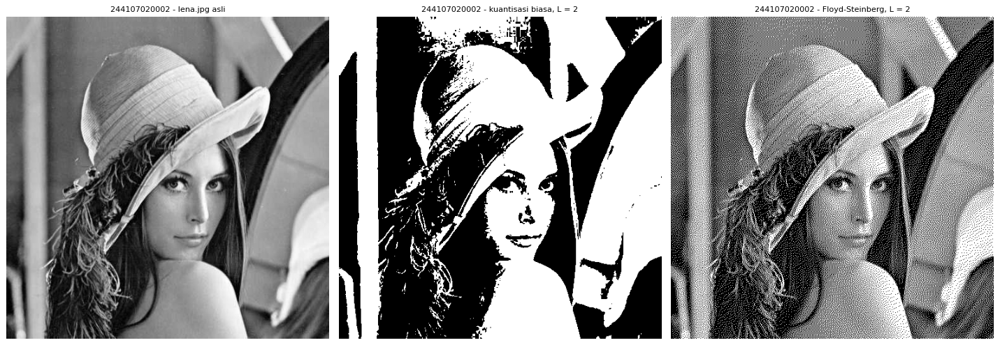

lena (gray, L=2): MSE setelah low-pass  FS = 12.8  |  kuantisasi biasa = 5178.6 | level unik: [  0 255]


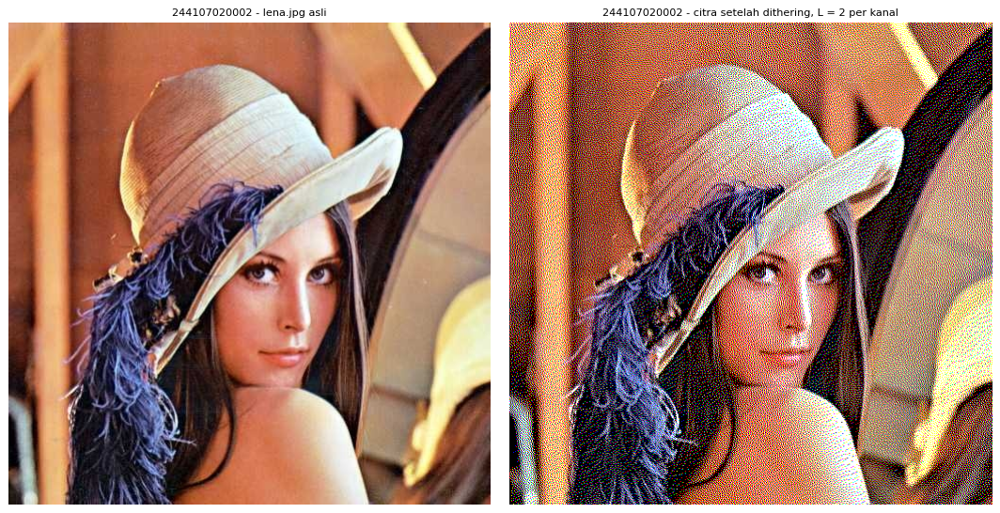

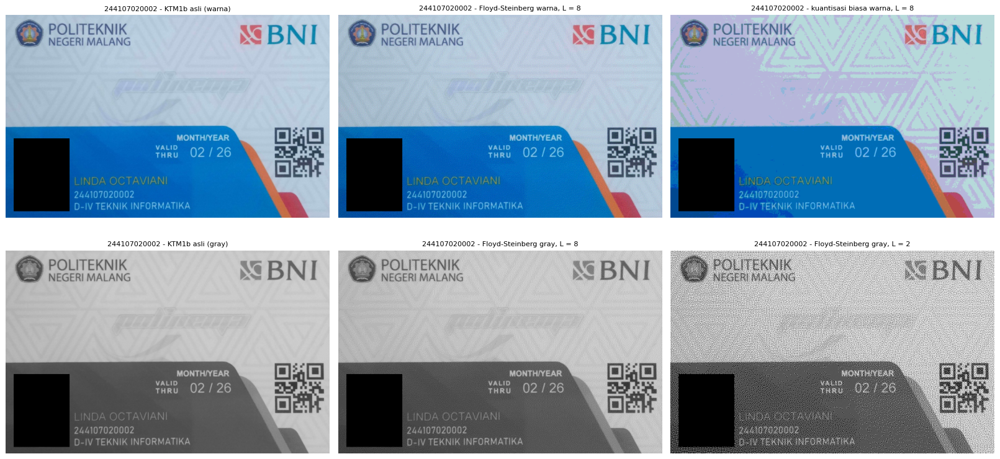

KTM1b gray L=8 : level unik = 7 | MSE low-pass FS = 0.51 | kuantisasi biasa = 95.57 | PSNR FS (pikselwise) = 24.40 dB


KTM1b gray L=2 : level unik = 2 | MSE low-pass FS = 6.97 | kuantisasi biasa = 4525.41 | PSNR FS (pikselwise) = 7.11 dB
waktu eksekusi sel ini: 22.0 s


In [16]:
import time
def fs_warna(bgr, L):
    return cv.merge([floyd_steinberg(bgr[:, :, i], L) for i in range(3)])   # kanal B, G, R terpisah

def kuantisasi_biasa(gray, L):
    step = 255.0/(L-1); return (np.round(gray/step)*step).astype(np.uint8)

def metrik_dither(asli, hasil, simple):
    # PSNR piksel-demi-piksel vs kemiripan setelah low-pass (simulasi pandangan mata)
    lp = lambda a: cv.GaussianBlur(a.astype(np.float32), (0, 0), 1.5)
    mse = lambda a, b: float(np.mean((lp(a)-lp(b))**2))
    return mse(asli, hasil), mse(asli, simple)

# ------- TAHAP 1: lena.jpg, grayscale, L = 2 (sesuai contoh modul) -------
t0 = time.time()
lena_g = baca_gray(CONTOH + '/lena.jpg')
lena_fs2 = floyd_steinberg(lena_g, 2)
fig, axs = plt.subplots(1, 3, figsize=(16, 5.5))
show(axs[0], lena_g, 'lena.jpg asli'); show(axs[1], kuantisasi_biasa(lena_g, 2), 'kuantisasi biasa, L = 2'); show(axs[2], lena_fs2, 'Floyd-Steinberg, L = 2')
plt.tight_layout(); plt.show()
m_fs, m_q = metrik_dither(lena_g, lena_fs2, kuantisasi_biasa(lena_g, 2))
print('lena (gray, L=2): MSE setelah low-pass  FS = %.1f  |  kuantisasi biasa = %.1f' % (m_fs, m_q), '| level unik:', np.unique(lena_fs2))

# tahap 1 berwarna (per kanal)
lena_c = cv.imread(CONTOH + '/lena.jpg'); lena_cfs = fs_warna(lena_c, 2)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
show(axs[0], lena_c, 'lena.jpg asli'); show(axs[1], lena_cfs, 'citra setelah dithering, L = 2 per kanal')
plt.tight_layout(); plt.show()

# ------- TAHAP 2: KTM1b.jpg, L = PARAM['L'] -------
Lp = PARAM['L']
ktm_b = cv.imread(F['b']); gray_b = cv.cvtColor(ktm_b, cv.COLOR_BGR2GRAY)
fs_b_gray = floyd_steinberg(gray_b, Lp); fs_b_col = fs_warna(ktm_b, Lp)
fs_b_gray2 = floyd_steinberg(gray_b, 2)
fig, axs = plt.subplots(2, 3, figsize=(18, 9))
show(axs[0, 0], ktm_b, 'KTM1b asli (warna)', 'b'); show(axs[0, 1], fs_b_col, f'Floyd-Steinberg warna, L = {Lp}', 'b'); show(axs[0, 2], kuantisasi_biasa(ktm_b, Lp), f'kuantisasi biasa warna, L = {Lp}', 'b')
show(axs[1, 0], gray_b, 'KTM1b asli (gray)', 'b'); show(axs[1, 1], fs_b_gray, f'Floyd-Steinberg gray, L = {Lp}', 'b'); show(axs[1, 2], fs_b_gray2, 'Floyd-Steinberg gray, L = 2', 'b')
plt.tight_layout(); plt.show()
for L_ in (Lp, 2):
    f = floyd_steinberg(gray_b, L_); q = kuantisasi_biasa(gray_b, L_); a, b_ = metrik_dither(gray_b, f, q)
    print('KTM1b gray L=%d : level unik = %d | MSE low-pass FS = %.2f | kuantisasi biasa = %.2f | PSNR FS (pikselwise) = %.2f dB' % (L_, len(np.unique(f)), a, b_, psnr(gray_b, f)))
print('waktu eksekusi sel ini: %.1f s' % (time.time() - t0))

**Jawaban E3-1.** Tahap 1 (lena.jpg, L = 2) menghasilkan citra dengan hanya dua level (0 dan 255) yang tetap tampak seperti foto berkat penyebaran error, sesuai contoh modul. Tahap 2 (KTM1b, L = 8): citra warna dan gray mempertahankan teks dan logo; setelah *low-pass* (simulasi pandangan mata) MSE terhadap citra asli hanya **0,51** untuk Floyd-Steinberg dibanding **95,57** untuk kuantisasi biasa (nearest) pada L = 8, dan **6,97** vs **4525,41** pada L = 2. Kuantisasi biasa menimbulkan *banding*/kontur palsu (terlihat pada latar kartu), sedangkan error diffusion menyamarkannya sebagai pola titik. PSNR piksel-demi-piksel Floyd-Steinberg rendah (24,40 dB pada L = 8; 7,11 dB pada L = 2) karena polanya berupa titik acak, namun secara visual (setelah rata-rata oleh mata) hasilnya mendekati asli. Jumlah level unik pada L = 8 adalah 7 (level tertinggi 255 tidak terpakai karena KTM1b tidak memiliki piksel yang sangat terang).

### E-3.3 Ekualisasi → dithering vs dithering langsung (lena_lc.jpg lalu KTM1a.jpg)

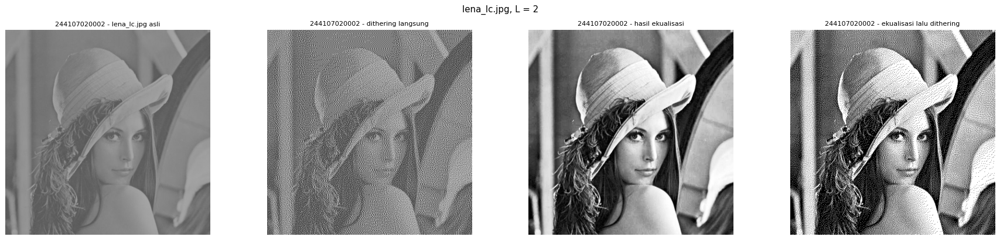

lena_lc: kontras RMS asli = 0.075, setelah HE = 0.289; level unik hasil dithering: [  0 255] / [  0 255]


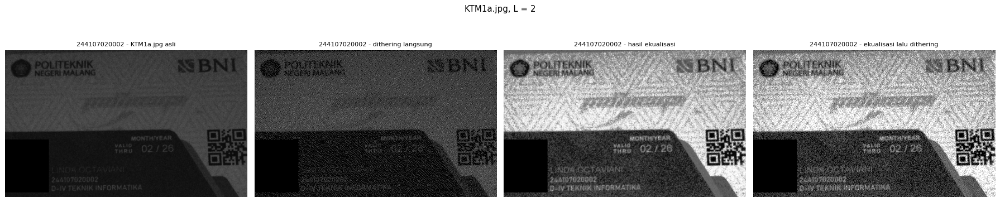

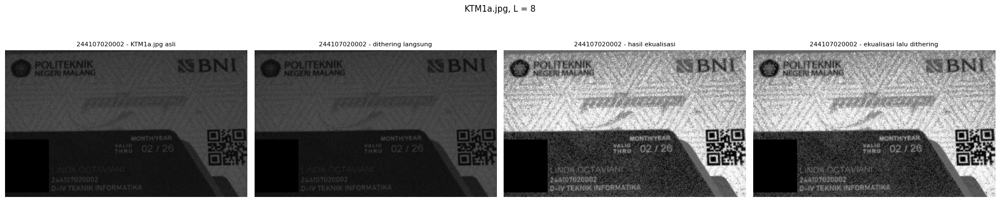

In [17]:
def empat_panel(gray, nama, L, k=None):
    langsung = floyd_steinberg(gray, L)
    he = cv.equalizeHist(gray)
    he_fs = floyd_steinberg(he, L)
    fig, axs = plt.subplots(1, 4, figsize=(20, 4.6))
    for ax, g, t in zip(axs, [gray, langsung, he, he_fs], [f'{nama} asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']):
        show(ax, g, t, k, fs=9)
    plt.suptitle(f'{nama}, L = {L}'); plt.tight_layout(); plt.show()
    return langsung, he, he_fs

# TAHAP 1: lena_lc.jpg (L = 2 seperti contoh modul)
lena_lc_g = baca_gray(CONTOH + '/lena_lc.jpg')
lo_lc, he_lc, hefs_lc = empat_panel(lena_lc_g, 'lena_lc.jpg', 2)
print('lena_lc: kontras RMS asli = %.3f, setelah HE = %.3f; level unik hasil dithering: %s / %s' % (kontras_rms(lena_lc_g), kontras_rms(he_lc), np.unique(lo_lc), np.unique(hefs_lc)))

# TAHAP 2: KTM1a.jpg
hasil_e3 = {}
for L_ in (2, PARAM['L']):
    hasil_e3[L_] = empat_panel(gray_a, 'KTM1a.jpg', L_, 'a')

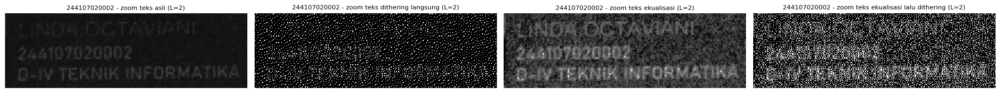

--- L = 2 ---
citra                        kontras RMS teks   tepi teks (LP)    rerata teks
asli                                    0.028             15.3           24.0
dithering langsung                      0.039             46.9           24.0
ekualisasi saja                         0.085             54.6           62.2
ekualisasi lalu dithering               0.089             67.4           62.3
  korelasi (LP) dengan acuan hasil ekualisasi, dithering langsung        : 0.694
  korelasi (LP) dengan acuan hasil ekualisasi, ekualisasi lalu dithering : 0.971


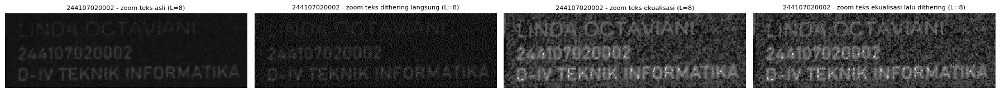

--- L = 8 ---
citra                        kontras RMS teks   tepi teks (LP)    rerata teks
asli                                    0.028             15.3           24.0
dithering langsung                      0.028             16.0           23.7
ekualisasi saja                         0.085             54.6           62.2
ekualisasi lalu dithering               0.085             54.8           61.7
  korelasi (LP) dengan acuan hasil ekualisasi, dithering langsung        : 0.954
  korelasi (LP) dengan acuan hasil ekualisasi, ekualisasi lalu dithering : 0.999


In [18]:
# zoom area nama/NIM + metrik keterbacaan (setelah low-pass, mensimulasikan pandangan mata)
lp = lambda a: cv.GaussianBlur(a.astype(np.float32), (0, 0), 1.2)
for L_ in (2, PARAM['L']):
    lo, he, hefs = hasil_e3[L_]
    fig, axs = plt.subplots(1, 4, figsize=(20, 3.4))
    for ax, g, t in zip(axs, [gray_a, lo, he, hefs], ['asli', 'dithering langsung', 'ekualisasi', 'ekualisasi lalu dithering']):
        ax.imshow(roi(g, 'teks'), cmap='gray', vmin=0, vmax=255, interpolation='nearest'); ax.set_title(NIM + f' - zoom teks {t} (L={L_})', fontsize=9); ax.axis('off')
    plt.tight_layout(); plt.show()
    print(f'--- L = {L_} ---')
    print('%-28s %16s %16s %14s' % ('citra', 'kontras RMS teks', 'tepi teks (LP)', 'rerata teks'))
    for t, g in [('asli', gray_a), ('dithering langsung', lo), ('ekualisasi saja', he), ('ekualisasi lalu dithering', hefs)]:
        r = roi(g, 'teks'); rl = lp(r)
        print('%-28s %16.3f %16.1f %14.1f' % (t, kontras_rms(rl), kuat_tepi(rl.astype(np.uint8)), r.mean()))
    # keterbacaan: kemiripan hasil dithering dengan citra ekualisasi (acuan terbaca) pada ROI teks
    ref = lp(roi(he, 'teks'))
    for t, g in [('dithering langsung', lo), ('ekualisasi lalu dithering', hefs)]:
        print('  korelasi (LP) dengan acuan hasil ekualisasi, %-26s: %.3f' % (t, np.corrcoef(lp(roi(g, 'teks')).ravel(), ref.ravel())[0, 1]))

**Jawaban E3-2.** Hasil pada area nama/NIM/prodi KTM1a (setelah *low-pass* σ = 1,2 untuk mensimulasikan pandangan mata):

| Urutan (L = 2) | Kontras teks | Tepi teks | Rerata area teks | Korelasi dgn acuan hasil ekualisasi |
|---|---|---|---|---|
| Citra asli | 0,028 | 15,3 | 24,0 | – |
| Dithering langsung | 0,039 | 46,9 | 24,0 | 0,694 |
| Ekualisasi saja | 0,085 | 54,6 | 62,2 | – |
| Ekualisasi lalu dithering | 0,089 | 67,4 | 62,3 | **0,971** |

Pada L = 8 (nilai pribadi) pola yang sama: dithering langsung 0,028 (≈ asli) vs ekualisasi lalu dithering 0,085 (≈ ekualisasi).

**Urutan yang lebih terbaca: ekualisasi dulu, baru dithering.** Pada KTM1a hampir seluruh piksel bernilai rendah (rerata area teks 24 dari 255), sehingga dithering langsung dengan L = 2 mengubah hampir semuanya menjadi hitam dan hanya menyisakan sedikit titik putih yang acak; huruf tenggelam bersama latar (korelasi 0,694). Error diffusion hanya mengawetkan *rata-rata lokal*, jadi bila rata-rata teks dan latar sama-sama dekat 0, perbedaannya tidak akan tampil. Ekualisasi lebih dulu memperlebar sebaran intensitas (rerata teks 24 → 62, kontras ×3) sehingga perbedaan teks dan latar menjadi perbedaan *kerapatan titik* yang jelas (korelasi 0,971 dengan citra ekualisasi). Urutan terbalik (dithering lalu ekualisasi) tidak berguna karena citra sudah hanya berisi 2 level (0 dan 255), sehingga tidak ada lagi sebaran yang dapat diratakan.